## Train Model

This notebook defines the model, trains it, and then evaluates it on the validation and test sets

Import libraries

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import LSTM, GRU, Dense, Bidirectional, BatchNormalization, Input, Add, Masking
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
import pdb
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, precision_recall_curve, auc, classification_report
import glob
import pickle
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


Define some constants related to the model

In [2]:
BATCH_SIZE = 64
INPUT_SEQ_LEN_MODEL1 = 10
INPUT_NUM_CH_MODEL1 = 5
INPUT_FEATS_MODEL2 = 29
# MODIFICATION: Updated to 29 after dropping EtCO2, Bilirubin_direct, Fibrinogen, TroponinI

Define a function to calculate the ROC

In [3]:
def roc(predictions, true, filename):
    predictions = predictions.flatten()
    true = true.flatten()

    thresh_vals = np.linspace(np.min(predictions), np.max(predictions), 50)
    results = []
    for thresh in thresh_vals:
        tmp_predictions = (predictions > thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(true, tmp_predictions).ravel()
        tpr = tp/(tp+fn)
        fpr = fp/(tn+fp)
        acc = (tp+tn)/(tn+fp+fn+tp)

        tmp_dict = {'acc': acc, 'tpr': tpr, 'fpr': fpr, 'thresh': thresh}
        results.append(tmp_dict)

    results = pd.DataFrame(results)
    results = results.sort_values(by='thresh', ascending=False)
    
    #calculate the AUC
    AUC = auc(results['fpr'].values, results['tpr'].values)

    plt.figure(figsize=(10,6))
    plt.plot(results['fpr'], results['tpr'], '*-')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC\nAUC=%.2f' % AUC)
    plt.tight_layout()
    plt.savefig('plots/ROC_%s.png' % filename, dpi=250)
    plt.show()

    results = results.sort_values(by='acc', ascending=False)
    final_thresh = results.head(1)['thresh'].values[0]

    return results, final_thresh


Load the data and set up the train, validation, and test sets

In [4]:
#load the training data
train = pd.read_pickle('train.pkl').reset_index(drop=True)

#define the validation set as 15% of the training set
N = len(train)
train = train.sample(frac=1).reset_index(drop=True)
val = train[:int(N*0.2)]
train = train[int(N*0.2):]

#separate out the training data
#note that input data for LSTM should be in the format of (number_samples, sequence_len, num_channels)
y_train = np.asarray(list(train['label']))
y_train = to_categorical(y_train)
X_train_cont = np.asarray(list(train['X_cont'].values))
X_train_cat = train.drop(['X_cont', 'label'], axis=1)

#for the mask layer, any NaN values need to be replaced by a unique value. use the constant np.pi
X_train_cat[X_train_cat.isna()] = np.pi
X_train_cat = np.asarray(list(X_train_cat.values))

#separate out the training data
y_val = np.asarray(list(val['label']))
y_val = to_categorical(y_val)
X_val_cont = np.asarray(list(val['X_cont'].values))
X_val_cat = val.drop(['X_cont', 'label'], axis=1)

#replace NaN with pi
X_val_cat[X_val_cat.isna()] = np.pi
X_val_cat = np.asarray(list(X_val_cat.values))

#load the test data
test = pd.read_pickle('test.pkl')
y_test = np.asarray(list(test['label']))
y_test = to_categorical(y_test)
X_test_cont = np.asarray(list(test['X_cont'].values))
X_test_cat = test.drop(['X_cont', 'label'], axis=1)

#replace NaN with pi
X_test_cat[X_test_cat.isna()] = np.pi
X_test_cat = np.asarray(list(X_test_cat.values))


Calculate the class weights

In [5]:
count_class_0 = np.sum(y_train[:,1].astype(int)==0)
count_class_1 = np.sum(y_train[:, 1].astype(int) == 1)
max_class_counts = np.max((count_class_0, count_class_1))
class_weights = {0: max_class_counts/count_class_0, 1: max_class_counts/count_class_1}
print('class weights -- no sepsis: {}, sepsis: {}'.format(class_weights[0], class_weights[1]))


class weights -- no sepsis: 1.0, sepsis: 44.733118971061096


Define the model using the functional API

In [6]:
input1 = Input(shape=(INPUT_SEQ_LEN_MODEL1, INPUT_NUM_CH_MODEL1))
model1 = Bidirectional(LSTM(100, kernel_regularizer=l2(0.001), return_sequences=True))(input1)
model1 = Bidirectional(LSTM(75, kernel_regularizer=l2(0.001)))(model1)
model1 = Dense(35, kernel_regularizer=l2(0.001), activation='relu')(model1)
model1 = BatchNormalization()(model1)
model1 = Dense(15, kernel_regularizer=l2(0.001), activation='relu')(model1)
model1 = BatchNormalization()(model1)

input2 = Input(shape=(INPUT_FEATS_MODEL2,))
model2 = Masking(mask_value=np.pi)(input2)
model2 = Dense(30, kernel_regularizer=l2(0.001), activation='relu')(model2)
model2 = BatchNormalization()(model2)
model2 = Dense(15, kernel_regularizer=l2(0.001), activation='relu')(model2)
model2 = BatchNormalization()(model2)

model_add = Add()([model1, model2])
output = Dense(2, kernel_regularizer=l2(0.001), activation='softmax')(model_add)

model = Model(inputs=[input1, input2], outputs=output)
model.compile(loss='categorical_crossentropy', optimizer='adam')
print(model.summary())



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 10, 5)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional (Bidirectional) │ (None, 10, 200)           │          84,800 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_1 (InputLayer)    │ (None, 29)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional_1               │ (None, 150)               │         165,600 │ bidirectional[0][0]        │
│ (Bidirectional)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ masking (Masking)             │ (None, 29)                │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal (NotEqual)          │ (None, 29)                │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 35)                │           5,285 │ bidirectional_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 30)                │             900 │ masking[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ any (Any)                     │ (None)                    │               0 │ not_equal[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 35)                │             140 │ dense[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 30)                │             120 │ dense_2[0][0], any[0][0]   │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 15)                │             540 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 15)                │             465 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 15)                │              60 │ dense_1[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 15)                │              60 │ dense_3[0][0], any[0][0]   │
│ (BatchNormalization)          │                           │               

 Total params: 258,002 (1007.82 KB)

 Trainable params: 257,812 (1007.08 KB)

 Non-trainable params: 190 (760.00 B)

None


In [7]:
# MODIFICATION: GRU model for comparison with LSTM
input1_gru = Input(shape=(INPUT_SEQ_LEN_MODEL1, INPUT_NUM_CH_MODEL1))
gru_branch = Bidirectional(GRU(100, kernel_regularizer=l2(0.001), return_sequences=True))(input1_gru)
gru_branch = Bidirectional(GRU(75, kernel_regularizer=l2(0.001)))(gru_branch)
gru_branch = Dense(35, kernel_regularizer=l2(0.001), activation='relu')(gru_branch)
gru_branch = BatchNormalization()(gru_branch)
gru_branch = Dense(15, kernel_regularizer=l2(0.001), activation='relu')(gru_branch)
gru_branch = BatchNormalization()(gru_branch)

input2_gru = Input(shape=(INPUT_FEATS_MODEL2,))
static_gru = Masking(mask_value=np.pi)(input2_gru)
static_gru = Dense(30, kernel_regularizer=l2(0.001), activation='relu')(static_gru)
static_gru = BatchNormalization()(static_gru)
static_gru = Dense(15, kernel_regularizer=l2(0.001), activation='relu')(static_gru)
static_gru = BatchNormalization()(static_gru)

gru_merged = Add()([gru_branch, static_gru])
gru_output = Dense(2, kernel_regularizer=l2(0.001), activation='softmax')(gru_merged)
gru_model = Model(inputs=[input1_gru, input2_gru], outputs=gru_output)
gru_model.compile(loss='categorical_crossentropy', optimizer='adam')
print(gru_model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 10, 5)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional_2               │ (None, 10, 200)           │          64,200 │ input_layer_2[0][0]        │
│ (Bidirectional)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_3 (InputLayer)    │ (None, 29)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional_3               │ (None, 150)               │         124,650 │ bidirectional_2[0][0]      │
│ (Bidirectional)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ masking_1 (Masking)           │ (None, 29)                │               0 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal_1 (NotEqual)        │ (None, 29)                │               0 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 35)                │           5,285 │ bidirectional_3[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_7 (Dense)               │ (None, 30)                │             900 │ masking_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ any_1 (Any)                   │ (None)                    │               0 │ not_equal_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_4         │ (None, 35)                │             140 │ dense_5[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_6         │ (None, 30)                │             120 │ dense_7[0][0], any_1[0][0] │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_6 (Dense)               │ (None, 15)                │             540 │ batch_normalization_4[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_8 (Dense)               │ (None, 15)                │             465 │ batch_normalization_6[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_5         │ (None, 15)                │              60 │ dense_6[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_7         │ (None, 15)                │              6

 Total params: 196,452 (767.39 KB)

 Trainable params: 196,262 (766.65 KB)

 Non-trainable params: 190 (760.00 B)

None


In [8]:
#just to check 
print(X_train_cat.shape)
print(X_val_cat.shape)
print(X_test_cat.shape)

(327129, 29)
(81782, 29)
(170267, 29)


Train the model

In [ ]:
checkpoint = ModelCheckpoint('model.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='auto')
earlystop = EarlyStopping(monitor='val_loss', min_delta=0, patience=5)
history = model.fit([X_train_cont, X_train_cat],
                    y_train,
                    batch_size=BATCH_SIZE,
                    epochs=50,
                    validation_data=([X_val_cont, X_val_cat], y_val),
                    callbacks=[earlystop, checkpoint],
                    class_weight=class_weights,
                    verbose=1)

#save the history
pickle.dump(history, open('history.pkl', 'wb'))

Epoch 1/50
5112/5112 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 1.0940
Epoch 1: val_loss improved from None to 0.54748, saving model to model.h5



Epoch 1: finished saving model to model.h5
5112/5112 ━━━━━━━━━━━━━━━━━━━━ 330s 64ms/step - loss: 1.0917 - val_loss: 0.5475
Epoch 2/50
5112/5112 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 1.0869
Epoch 2: val_loss did not improve from 0.54748
5112/5112 ━━━━━━━━━━━━━━━━━━━━ 295s 58ms/step - loss: 1.0852 - val_loss: 0.6700
Epoch 3/50
5111/5112 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 1.0778
Epoch 3: val_loss did not improve from 0.54748
5112/5112 ━━━━━━━━━━━━━━━━━━━━ 298s 58ms/step - loss: 1.0854 - val_loss: 0.8449
Epoch 4/50
5112/5112 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 1.0731
Epoch 4: val_loss improved from 0.54748 to 0.45340, saving model to model.h5



Epoch 4: finished saving model to model.h5
5112/5112 ━━━━━━━━━━━━━━━━━━━━ 307s 60ms/step - loss: 1.0829 - val_loss: 0.4534
Epoch 5/50
5112/5112 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 1.0711
Epoch 5: val_loss did not improve from 0.45340
5112/5112 ━━━━━━━━━━━━━━━━━━━━ 348s 68ms/step - loss: 1.0764 - val_loss: 0.5760
Epoch 6/50
5112/5112 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 1.0726
Epoch 6: val_loss did not improve from 0.45340
5112/5112 ━━━━━━━━━━━━━━━━━━━━ 282s 55ms/step - loss: 1.0786 - val_loss: 0.8375
Epoch 7/50
5112/5112 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 1.0632
Epoch 7: val_loss improved from 0.45340 to 0.22606, saving model to model.h5



Epoch 7: finished saving model to model.h5
5112/5112 ━━━━━━━━━━━━━━━━━━━━ 339s 66ms/step - loss: 1.0751 - val_loss: 0.2261
Epoch 8/50
5111/5112 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 1.0669
Epoch 8: val_loss did not improve from 0.22606
5112/5112 ━━━━━━━━━━━━━━━━━━━━ 306s 60ms/step - loss: 1.0679 - val_loss: 0.3144
Epoch 9/50
5112/5112 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 1.0438
Epoch 9: val_loss improved from 0.22606 to 0.15385, saving model to model.h5



Epoch 9: finished saving model to model.h5
5112/5112 ━━━━━━━━━━━━━━━━━━━━ 285s 56ms/step - loss: 1.0589 - val_loss: 0.1538
Epoch 10/50
1192/5112 ━━━━━━━━━━━━━━━━━━━━ 4:15 65ms/step - loss: 1.0436

Plot the training/validation loss

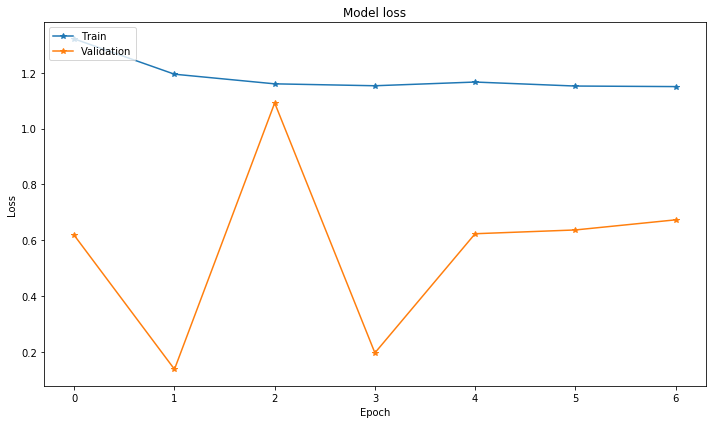

In [9]:
# Plot training & validation loss values
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], '*-')
plt.plot(history.history['val_loss'], '*-')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.savefig('plots/loss.png', dpi=250)
plt.show()
plt.close()


Evaluate the model on the validation set

Evaluate the model on the test set

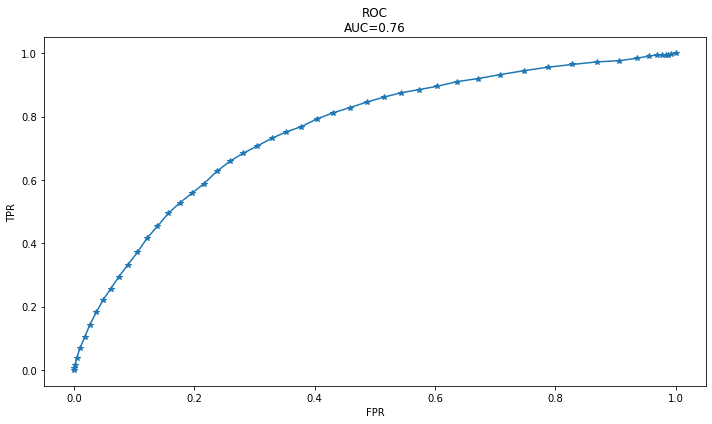

In [11]:
# Validation ROC
predictions = model.predict([X_val_cont, X_val_cat])
results_df, thresh_final = roc(predictions[:,1].flatten(), y_val[:,1].flatten(), 'val')
results_df = results_df.sort_values(by='fpr')

# MODIFICATION: Additional evaluation metrics for imbalanced dataset
print("=== LSTM Model Evaluation ===")
y_pred_prob = model.predict([X_test_cont, X_test_cat])
y_pred_binary = np.argmax(y_pred_prob, axis=1)
y_true_binary = np.argmax(y_test, axis=1)
print(classification_report(y_true_binary, y_pred_binary, target_names=['No Sepsis', 'Sepsis']))
f1 = f1_score(y_true_binary, y_pred_binary)
precision, recall, _ = precision_recall_curve(y_true_binary, y_pred_prob[:, 1])
pr_auc = auc(recall, precision)
print(f"F1 Score: {f1:.4f}")
print(f"Precision-Recall AUC: {pr_auc:.4f}")

# Test ROC plot
results_df, thresh_final = roc(y_pred_prob[:,1].flatten(), y_test[:,1].flatten(), 'test')
results_df = results_df.sort_values(by='fpr')


In [10]:
print(X_train_cat.shape)
print(X_val_cat.shape)
print(X_test_cat.shape)

(327129, 29)
(81782, 29)
(170267, 29)


In [ ]:
print(X_train_cat.shape)
print(X_val_cat.shape)
print(X_test_cat.shape)

In [22]:
print(INPUT_FEATS_MODEL2)

30
